# 🌙 STEP 4: Exploratory Data Analysis (EDA)

Submission-ready STEP 4 EDA notebook using `merged_features_v2.csv`.

This notebook directly supports STEP 5 (Clustering).

In [14]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1. 데이터 로딩 & 결측치 체크





In [15]:

import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/팀프로젝트/merged_features_v3.csv")

print("Shape:", df.shape)
print("Total missing values:", df.isna().sum().sum())
df.head()


Shape: (172, 44)
Total missing values: 0


,TRDAR_NO,TRDAR_NM,SIGNGU_NM,DATA_STRD_YM,GRFA_SM,RSDNTL_BULD_GRFA,RSDNTL_BULD_EXCL_GRFA,MOAV_TOTL_LVLH_POPNO,MOAV_NAOR_LVLH_POPNO,MOAV_STPRD_FRNR_LVLH_POPNO,...,TNTTH_TIZN_TOTL_LVLH_POPNO,peak_hour_col,day_ratio,night_ratio,foreigner_ratio,population_density,short_foreigner_ratio,visitor_ratio,visit_intensity,transition_ratio
0,10000,목동역1번 출구,양천구,202510,207580.66,64851.08,142729.58,5257.94,5125.80,12.32,...,5108.45,SVNTN_TIZN_TOTL_LVLH_POPNO,0.377377,0.256338,0.025394,0.025330,0.002343,0.707530,0.017921,0.366285
1,10001,까치산역2번 출구,강서구,202510,128728.71,69566.61,59162.10,13935.64,13401.64,182.55,...,14183.93,TNTT_TIZN_TOTL_LVLH_POPNO,0.363345,0.272281,0.038452,0.108256,0.013100,0.645701,0.069901,0.364374
2,10002,서울화곡4동우체국,강서구,202510,95733.53,37339.88,58393.65,1012.56,981.59,2.15,...,1017.98,NNTN_TIZN_TOTL_LVLH_POPNO,0.374917,0.268628,0.032087,0.010577,0.002123,0.655359,0.006932,0.356455
3,10003,우장산역4번 출구,강서구,202510,82426.18,24010.56,58415.62,1227.44,1212.81,3.64,...,1072.31,EGHTN_TIZN_TOTL_LVLH_POPNO,0.393553,0.281597,0.012620,0.014891,0.002966,0.709705,0.010568,0.324850
4,10004,서울화곡본동우편취급국,강서구,202510,119223.18,13447.84,105775.34,2628.53,2526.74,29.53,...,3197.10,TNTTH_TIZN_TOTL_LVLH_POPNO,0.355012,0.271243,0.038786,0.022047,0.011234,0.891765,0.019661,0.373744


## 2. 핵심 파생변수 분포 분석

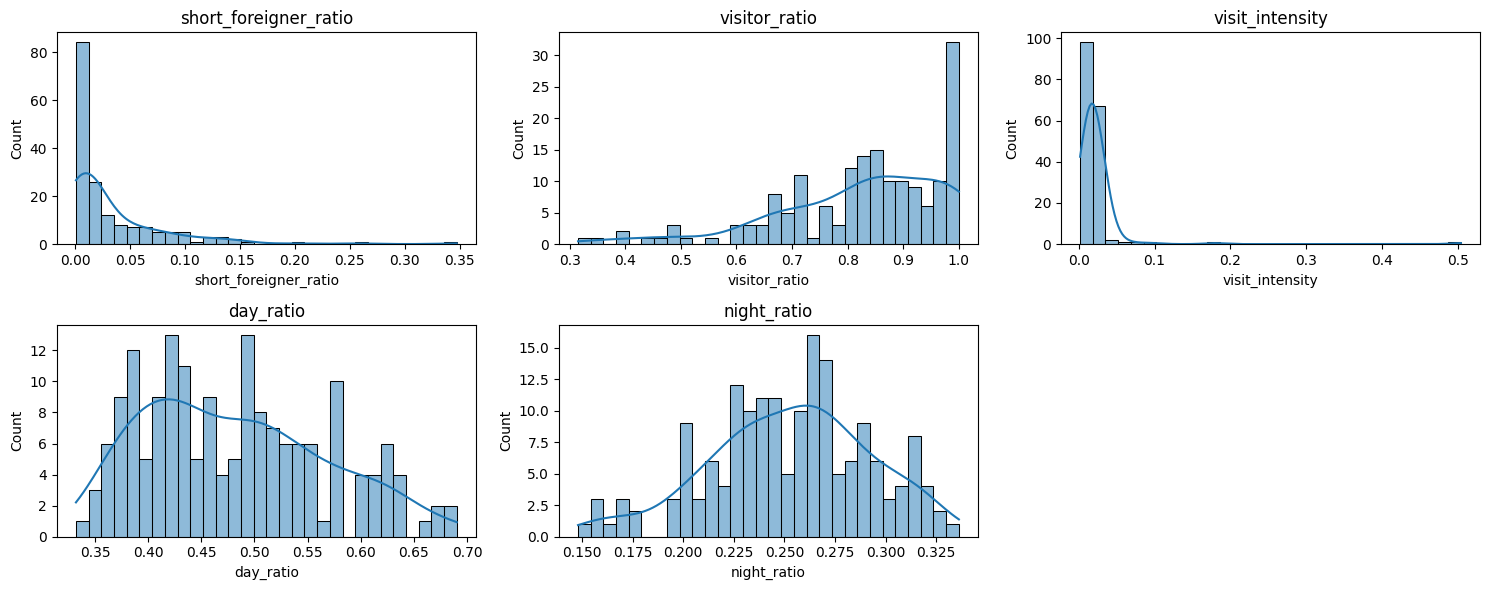

In [16]:

import matplotlib.pyplot as plt
import seaborn as sns

features = [
    'short_foreigner_ratio',
    # 단기 외국인 비중 = 단기 외국인 생활인구 / 전체 생활인구
    # 단기 외국인 = 관광, 출장, 단기 체류 목적 방문자

    # 이 비율이 높다는 것은:
    # 해당 상권이 관광·쇼핑·숙박·외식 목적의 공간일 가능성이 큼
    # 일상적 생활권보다는 비일상적 소비 공간에 가깝다는 의미 = 관광형 상권의 핵심 지표


    'visitor_ratio',
    # 방문 비중 = 전체 방문인구 / (전체 생활인구 + 전체 방문인구)
    # 값이 높다 -> 사람들이 일부러 찾아오는 상권
    # 값이 낮다 -> 사람들이 그냥 머무는 상권
    # 방문 중심 상권 vs 그냥 머무는 상권(원래 살고 있던 주거인) = 소비 목적인가? vs 생활 기반인가?

    'visit_intensity',
    # 방문 강도 = 전체 방문인구 / 상권 연면적
    # 좁은 면적 -> 혼잡, 소비, 상업성이 강함 = 골목 상권, 핵심 상업지, 관광 밀집 지역
    # 넓은 면적 -> 업무/복합/저밀 상권 = 대형 업무지구, 주거/업무혼합 지역

    'day_ratio', # 주간 비율
    'night_ratio' # 야간 비율
    # 주간 비율 = 주간(09~17시) 생활인구 합 / 전체 생활인구
    # 야간 비율 = 야간(18~23시) 생활인구 합 / 전체 생활인구
    # 주간 비율 ↑ -> 출근/업무/상업 중심 상권
    # 야간 비율 ↑ -> 주거/유흥/야간 소비 상권
]

plt.figure(figsize=(15,6))
for i, col in enumerate(features):
    plt.subplot(2,3,i+1)
    sns.histplot(df[col], bins=30, kde=True)
    plt.title(col)

plt.tight_layout()
plt.show()


| 파생변수      | 설명하는 질문         |
| --------- | --------------- |
| 단기 외국인 비중 | 관광 상권인가?        |
| 방문 비중     | 사람들이 일부러 찾아오는가? |
| 방문 강도     | 얼마나 빽빽하게 몰리는가?  |
| 주간/야간 비율  | 언제 가장 활성화되는가?   |


## 2-1 새벽 비율 변수 유의성 확인

In [17]:
# 'transition_ratio'= 새벽 비율
# 새벽 비율 = 새벽(00~08시) 생활인구 합 / 전체 생활인구
# 출근 시간대를 포함하므로 통과형 상권 분석 가능성 존재
df['transition_ratio'].describe()

,transition_ratio
count,172.000000
mean,0.266013
std,0.065375
min,0.113890
25%,0.216846
50%,0.267773
75%,0.312350
max,0.393751


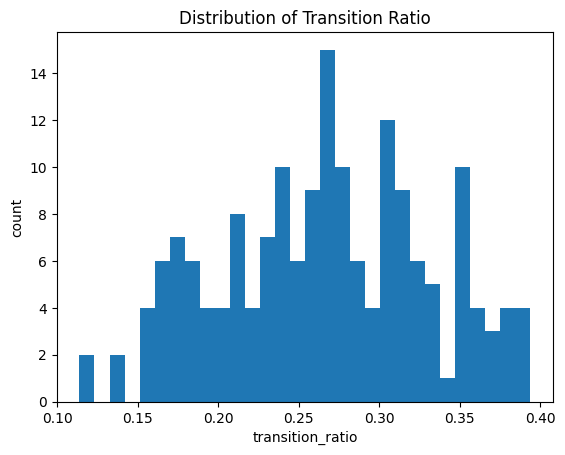

In [25]:
import matplotlib.pyplot as plt

plt.hist(df['transition_ratio'], bins=30)
plt.title('Distribution of Transition Ratio')
plt.xlabel('transition_ratio')
plt.ylabel('count')
plt.show()


In [26]:
# 타 변수와의 상관관계 분석
df[['transition_ratio', 'day_ratio', 'visit_intensity']].corr()

,transition_ratio,day_ratio,visit_intensity
transition_ratio,1.000000,-0.895367,-0.028821
day_ratio,-0.895367,1.000000,0.009311
visit_intensity,-0.028821,0.009311,1.000000


## 3. 서울 상권의 "평균 시간대 패턴" 확인

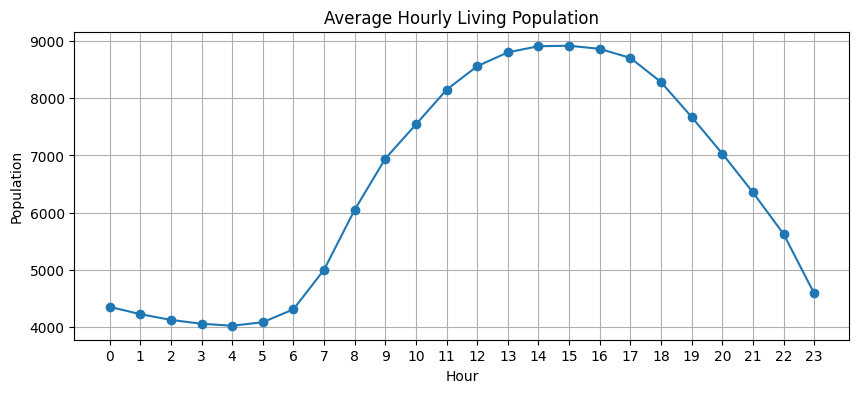

Peak hour: 15
Minimum hour: 4


In [18]:

import numpy as np
import matplotlib.pyplot as plt

order = [
    'ZERO','ONE','TWO','THREE','FOUR','FIVE','SIX','SEVEN','EIGHT','NINE','TEN','ELEVEN','TLV',
    'THIRTEEN','FOURTEEN','FFTN','SXTN','SVNTN','EGHTN','NNTN','TNT','TNONE','TNTT','TNTTH'
]
hour_cols = [f"{o}_TIZN_TOTL_LVLH_POPNO" for o in order]

avg_hourly = df[hour_cols].mean()

plt.figure(figsize=(10,4))
plt.plot(range(24), avg_hourly.values, marker='o')
plt.xticks(range(24))
plt.title("Average Hourly Living Population")
plt.xlabel("Hour")
plt.ylabel("Population")
plt.grid(True)
plt.show()

print("Peak hour:", int(np.argmax(avg_hourly.values)))
print("Minimum hour:", int(np.argmin(avg_hourly.values)))


서울시 전체 상권 평균 생활인구는 오후3시에 최대 오전4시에 최소로 나타났다.

-> 전형적인 도시형 패턴 (오전 이후 증가 -> 오후 피크 -> 야간 감소)

## 4. "관광형 상권 후보" 탐색 (단기 외국인 비중 상위)

In [19]:

# 관광형 상권 -> 단기 외국인 비중을 관광성의 핵심 지표로 사용한다.
# 단기 외국인 비중 상위 Top 10
df.sort_values(
    'short_foreigner_ratio', ascending=False
).head(10)[
    ['TRDAR_NM','SIGNGU_NM','short_foreigner_ratio','visitor_ratio']
]


,TRDAR_NM,SIGNGU_NM,short_foreigner_ratio,visitor_ratio
64,명동역6번 출구,중구,0.347227,0.999490
61,서울소공동우체국,중구,0.257109,0.994828
79,을지로3가역8번 출구,중구,0.204907,0.930897
62,회현역5번 출구,중구,0.160576,0.993833
78,을지로4가역1번 출구,중구,0.148934,0.825552
24,홍대입구역9번 출구,마포구,0.144753,0.853110
65,을지로입구역3번 출구,중구,0.134874,0.999296
68,종로3가역6번 출구,종로구,0.133527,0.961832
77,동대문역사문화공원역14번 출구,중구,0.131988,0.991169
23,홍대입구역3번 출구,마포구,0.126970,0.780560


## 5. "야간 집중 상권" 탐색 (night_ratio 상위)

In [20]:
# 주간/야간 상권을 파악하여 다른 지표와 결합하여 해석할 것(보조축 개념)

df.sort_values(
    'night_ratio', ascending=False
).head(10)[
    ['TRDAR_NM','SIGNGU_NM','night_ratio','day_ratio','visitor_ratio']
]


,TRDAR_NM,SIGNGU_NM,night_ratio,day_ratio,visitor_ratio
166,방이역1번 출구,송파구,0.336215,0.492093,0.836172
145,건대입구역1번 출구,광진구,0.328634,0.362746,0.658000
27,신림역4번 출구,관악구,0.326708,0.418869,0.860562
157,불암지구대,노원구,0.321127,0.563688,1.000000
57,사당역11번 출구,서초구,0.321047,0.412641,0.661149
162,서울잠실우체국,송파구,0.317938,0.414433,0.868020
56,사당역8번 출구,동작구,0.317411,0.401884,0.723676
24,홍대입구역9번 출구,마포구,0.316390,0.433714,0.853110
152,군자역5번 출구,광진구,0.315171,0.442925,0.928172
87,혜화역2번 출구,종로구,0.314561,0.493309,0.943618


## 6. 파생변수 간 산점도




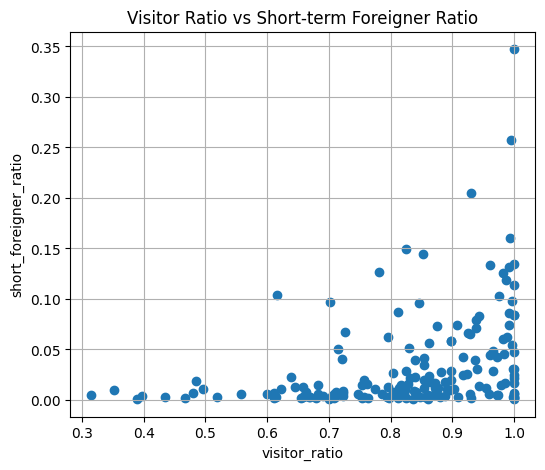

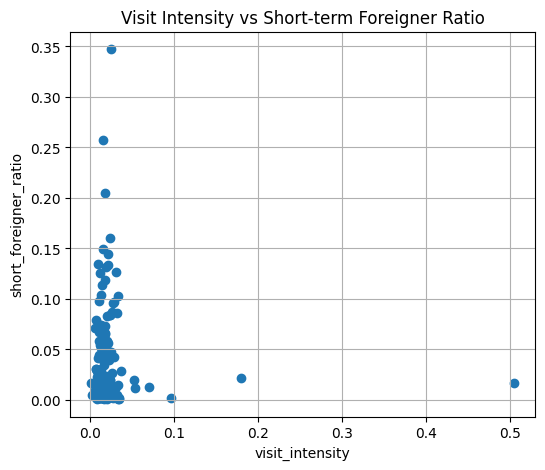

In [21]:

import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
plt.scatter(df['visitor_ratio'], df['short_foreigner_ratio'])
plt.xlabel("visitor_ratio")
plt.ylabel("short_foreigner_ratio")
plt.title("Visitor Ratio vs Short-term Foreigner Ratio")
plt.grid(True)
plt.show()

plt.figure(figsize=(6,5))
plt.scatter(df['visit_intensity'], df['short_foreigner_ratio'])
plt.xlabel("visit_intensity")
plt.ylabel("short_foreigner_ratio")
plt.title("Visit Intensity vs Short-term Foreigner Ratio")
plt.grid(True)
plt.show()


방문 중심 상권이 많다. = 사람들이 찾아오는 상권이다.
단기 외국인 비중이 높은 상권은 극소수 = 관광 성격은 극소수다.

=> 방문 비중이 높은 상권은 다수 존재하지만, 단기 외국인 비중이 동시에 높은 상권은 소수에 불과하여 관광형 상권이 뚜렷하게 구분됨을 확인하였다.


단기 외국인 비중이 높은 상권은 방문 강도 역시 높은 경향을 보이지만,

방문 강도만으로 관광형 상권을 식별하기에는 한계가 있어
외국인 비중 지표와의 결합이 필요함을 확인하였다.

## 7. 파생변수 간 상관관계 분석

In [22]:
# day_ratio + night_ratio 값 확인
(df['day_ratio'] + df['night_ratio']).describe()

,0
count,172.000000
mean,0.733987
std,0.065375
min,0.606249
25%,0.687650
50%,0.732227
75%,0.783154
max,0.886110


In [23]:

corr_cols = [
    'day_ratio','night_ratio','visitor_ratio',
    'short_foreigner_ratio','visit_intensity','population_density'
]

df[corr_cols].corr()


,day_ratio,night_ratio,visitor_ratio,short_foreigner_ratio,visit_intensity,population_density
day_ratio,1.000000,-0.677646,0.577040,0.383189,0.009311,-0.056638
night_ratio,-0.677646,1.000000,-0.363885,-0.293471,0.027517,0.078068
visitor_ratio,0.577040,-0.363885,1.000000,0.355922,0.137033,0.044694
short_foreigner_ratio,0.383189,-0.293471,0.355922,1.000000,-0.030689,-0.064869
visit_intensity,0.009311,0.027517,0.137033,-0.030689,1.000000,0.992751
population_density,-0.056638,0.078068,0.044694,-0.064869,0.992751,1.000000


| 관계                                    | 상관계수       | 해석                  |
| ------------------------------------- | ---------- | ------------------- |
| day_ratio ↔ visitor_ratio             | **+0.577** | 주간 활동이 강할수록 방문 중심   |
| night_ratio ↔ visitor_ratio           | **-0.364** | 야간 중심 상권은 방문 비중 낮아짐 |
| visitor_ratio ↔ short_foreigner_ratio | **+0.356** | 관광 상권은 방문 중심이긴 함    |
| day_ratio ↔ short_foreigner_ratio     | **+0.383** | 관광 상권은 주간 활동 비중이 큼  |
| visit_intensity ↔ population_density  | **+0.993** | 사실상 동일 지표           |


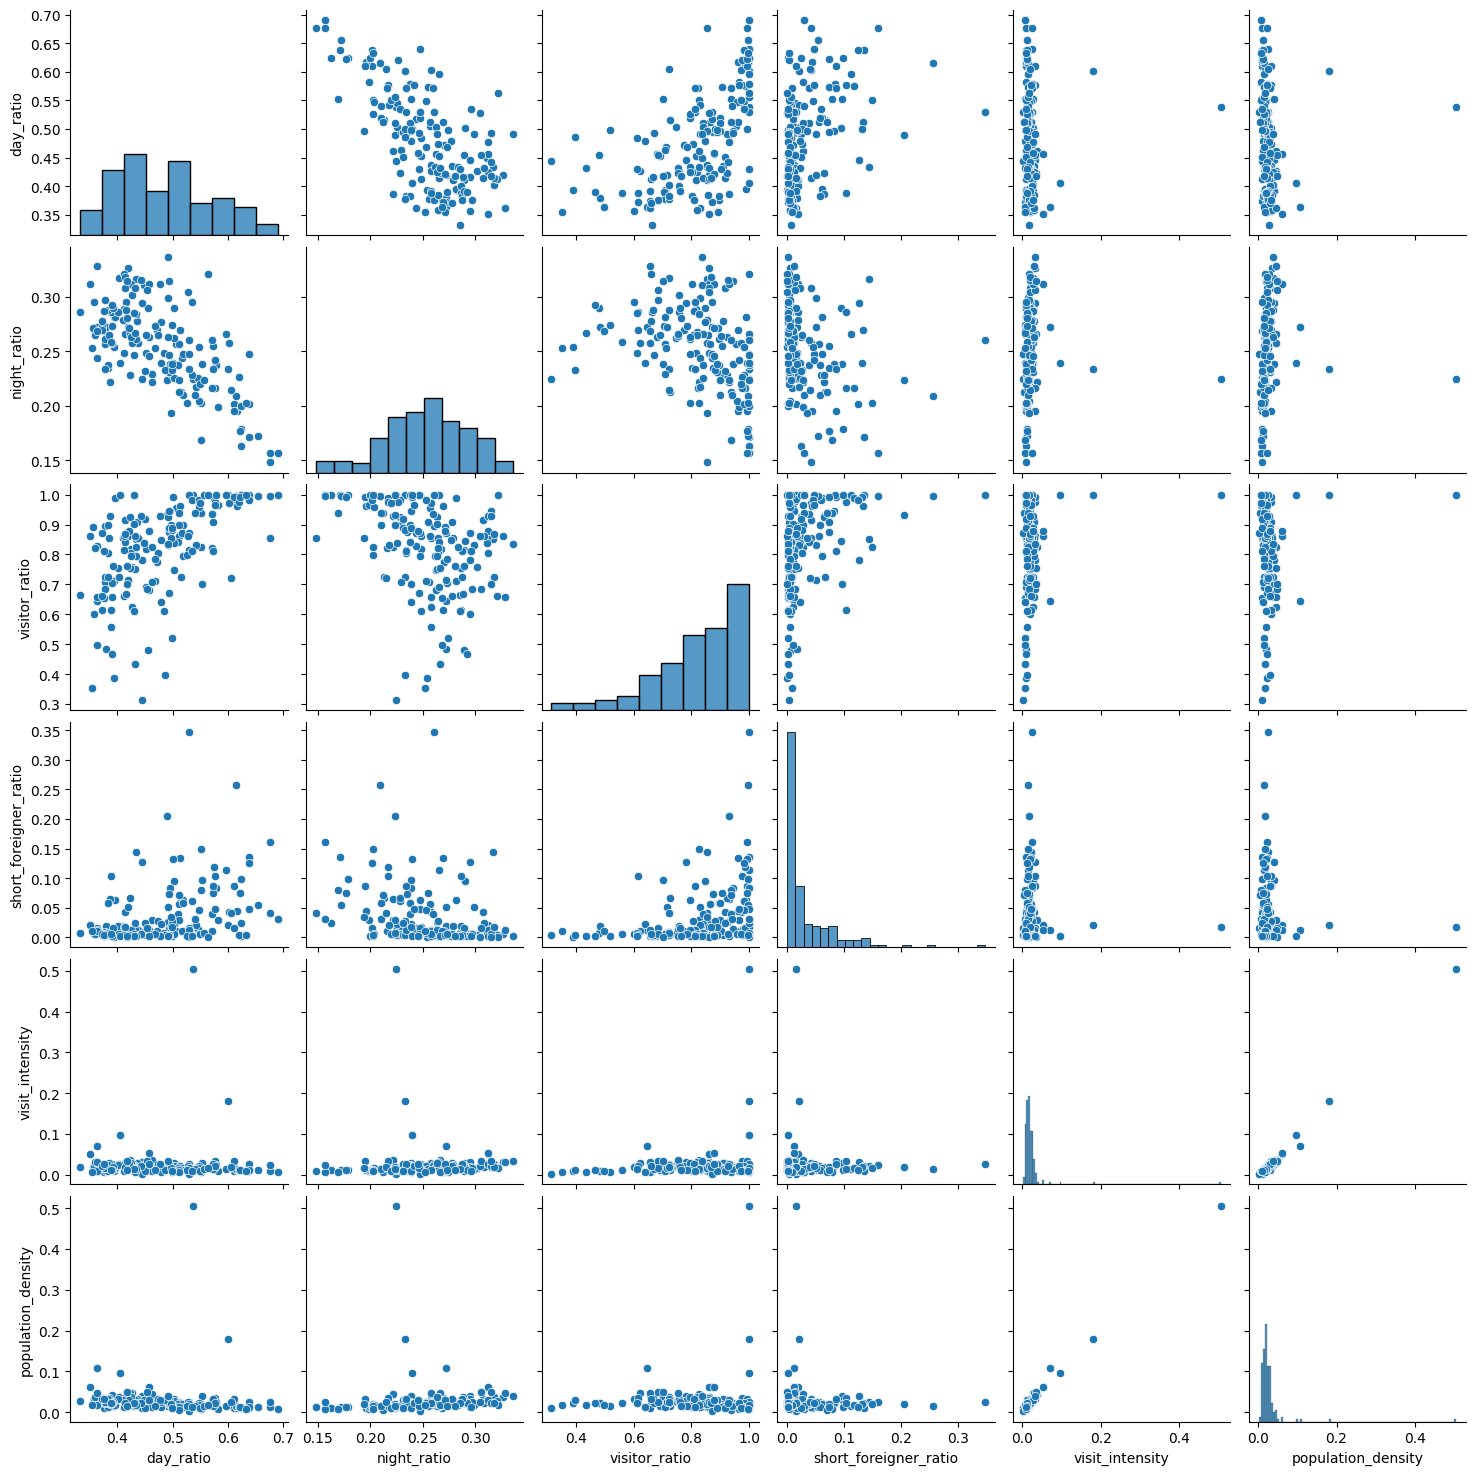

In [24]:
import seaborn as sns

sns.pairplot(df[corr_cols])
plt.show()

## ✅ STEP 4 Summary

- Tourism-oriented commercial areas are clearly identified by high short-term foreigner ratios.
- Visitor-based and time-based metrics show distinct clustering potential.
- Dataset is ready for STEP 5: Commercial Area Clustering.